<h1><center><b>💻 Practice 13:</b> </br> Heterogeneous GRL</center></h1>

# 1. metapath2vec: Scalable Representation Learning for Heterogeneous Networks


In [49]:
import numpy as np
import networkx as nx
import random
import threading
from collections import defaultdict
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import time
from threading import Lock

## 1.1. Word2Vec

In [50]:
class Word2Vec:
    def __init__(self, vector_size=128, window=5, negative=5, alpha=0.025, 
                 min_count=1, sg=1, epochs=5, num_threads=4):
        self.vector_size = vector_size
        self.window = window
        self.negative = negative
        self.alpha = alpha
        self.min_count = min_count
        self.sg = sg
        self.epochs = epochs
        self.num_threads = num_threads
        
        self.vocab = defaultdict(int)
        self.index2word = []
        self.word2index = {}
        self.syn0 = None      # Input vectors
        self.syn1neg = None   # Output vectors
        self.table = None
        self.table_size = int(1e8)
        self.lock = Lock()
    
    def build_vocab(self, sentences):
        for sentence in sentences:
            for word in sentence:
                self.vocab[word] += 1
        self.vocab = {w: f for w, f in self.vocab.items() if f >= self.min_count}
        self.index2word = list(self.vocab.keys())
        self.word2index = {word: idx for idx, word in enumerate(self.index2word)}
        print(f"Vocabulary size: {len(self.vocab)}")
    
    def init_unigram_table(self):
        power = 0.75
        norm = sum(freq ** power for freq in self.vocab.values())
        table = []
        for word, freq in self.vocab.items():
            p = (freq ** power) / norm
            table += [self.word2index[word]] * int(p * self.table_size)
        self.table = np.array(table, dtype=np.int32)
    
    def init_net(self):
        vocab_size = len(self.vocab)
        self.syn0 = (np.random.rand(vocab_size, self.vector_size) - 0.5) / self.vector_size
        self.syn1neg = np.zeros((vocab_size, self.vector_size))
        self.init_unigram_table()
    
    def train_pair(self, word_idx, context_idxs, alpha):
        for context_idx in context_idxs:
            self.update(word_idx, context_idx, alpha)
    
    def update(self, word_idx, context_idx, alpha):
        # Negative sampling
        neg_samples = np.random.choice(self.table, self.negative)
        labels = np.array([1] + [-1] * self.negative)
        target_idxs = np.concatenate(([context_idx], neg_samples))
        
        # Forward
        u = self.syn0[word_idx]
        v = self.syn1neg[target_idxs]
        prod = np.dot(u, v.T)
        
        # === FIX: Numerical stability ===
        prod = np.clip(prod, -10, 10)   # Prevent overflow
        
        sigmoid = 1 / (1 + np.exp(-prod))
        g = (sigmoid - labels) * alpha   # gradient
        
        # Update with lock
        with self.lock:
            self.syn0[word_idx] -= np.dot(g, v)
            self.syn1neg[target_idxs] -= np.outer(g, u)
    
    def train_model_thread(self, sentences_chunk, thread_id):
        random.seed(thread_id)
        alpha = self.alpha
        for epoch in range(self.epochs):
            alpha_decay = alpha * (1 - epoch / self.epochs)  # linear decay
            for sentence in sentences_chunk:
                sentence = [w for w in sentence if w in self.word2index]
                for i, word in enumerate(sentence):
                    current_idx = self.word2index[word]
                    start = max(0, i - self.window)
                    end = min(len(sentence), i + self.window + 1)
                    context = [self.word2index[sentence[j]] for j in range(start, end) if j != i]
                    if context:
                        self.train_pair(current_idx, context, alpha_decay)
    
    def train(self, sentences):
        self.build_vocab(sentences)
        self.init_net()
        
        # Split data for threads
        chunk_size = len(sentences) // self.num_threads
        threads = []
        for t in range(self.num_threads):
            start = t * chunk_size
            end = None if t == self.num_threads-1 else (t+1)*chunk_size
            chunk = sentences[start:end]
            thread = threading.Thread(
                target=self.train_model_thread, 
                args=(chunk, t)
            )
            threads.append(thread)
            thread.start()
        
        for thread in threads:
            thread.join()
        
        print("Training completed!")

## 1.2. Metapath2Vec

**Metapath2Vec** extends the Skip-Gram model by using **meta-path guided random walks** to generate semantically meaningful neighborhoods for nodes of different types.

### Metapath2Vec Process
Metapath2Vec learns embedding vectors for nodes through the following process:

1. **Generate meta-path guided random walks**.
2. **Treat the walks as sentences** and apply the heterogeneous Skip-Gram model with negative sampling.
3. Nodes that co-occur frequently in meta-path guided walks will have similar embeddings.

### Key Concept: Meta-Path
A **meta-path** $\mathcal{P}$ is a sequence of node types that defines a semantic relationship:
$$
\mathcal{P} = A_1 \xrightarrow{R_1} A_2 \xrightarrow{R_2} \dots \xrightarrow{R_l} A_{l+1}
$$

**Common meta-paths on DBLP:**
- **APA**: Author → Paper → Author (co-authorship)
- **APCPA**: Author → Paper → Conference → Paper → Author
- **APTPA**: Author → Paper → Term → Paper → Author

### Objective Function
Metapath2Vec maximizes the likelihood of a node's heterogeneous neighborhood using Skip-Gram:

$$
\max_{\theta} \sum_{v \in V} \sum_{t \in \mathcal{T}_V} \sum_{c_t \in N_t(v)} \log Pr(c_t | v ; \theta)
$$

where:
- $N_t(v)$: heterogeneous neighborhood of node $v$ of type $t$
- $Pr(c_t | v ; \theta)$: probability defined by softmax (approximated with negative sampling)

In [51]:
class Metapath2Vec:
    def __init__(self, graph, vector_size=128, window=5, min_count=1, 
                 workers=4, epochs=5, negative=5, walk_length=10, num_walks=10):
        self.graph = graph
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.workers = workers
        self.epochs = epochs
        self.negative = negative
        self.walk_length = walk_length
        self.num_walks = num_walks
        self.sentences = []
    
    def random_walk_metapath(self, start_node, metapath):
        walk = [start_node]
        current = start_node
        mp_idx = 0
        
        for _ in range(self.walk_length - 1):
            next_type = metapath[(mp_idx + 1) % len(metapath)]
            neighbors = [n for n in self.graph.neighbors(current) 
                        if self.graph.nodes[n].get('type') == next_type]
            
            if not neighbors:
                break
            current = random.choice(neighbors)
            walk.append(current)
            mp_idx += 1
        return [str(node) for node in walk]  # Convert to string for embedding
    
    def generate_walks(self, metapath):
        print(f"Generating walks using metapath: {metapath}")
        self.sentences = []
        nodes = [n for n in self.graph.nodes() if self.graph.nodes[n].get('type') == metapath[0]]
        
        for _ in range(self.num_walks):
            random.shuffle(nodes)
            for node in nodes:
                walk = self.random_walk_metapath(node, metapath)
                if len(walk) >= 3:  # Minimum meaningful length
                    self.sentences.append(walk)
        print(f"Generated {len(self.sentences)} walks")
        return self.sentences
    
    def train(self, metapath=['author', 'paper', 'author']):
        walks = self.generate_walks(metapath)
        self.model = Word2Vec(
            vector_size=self.vector_size,
            window=self.window,
            negative=self.negative,
            alpha=0.025,
            min_count=self.min_count,
            epochs=self.epochs,
            num_threads=self.workers
        )
        self.model.train(walks)
        return self.model

## 1.3. Create DBLP-like dataset and train

In [52]:
dataset = nx.Graph()  # Create synthetic DBLP-like graph

# Create synthetic DBLP-style heterogeneous graph
for i in range(300):
    dataset.add_node(f"a{i}", type='author')
for i in range(800):
    dataset.add_node(f"p{i}", type='paper')

for a in range(300):
    for p in range(800):
        if random.random() < 0.015:
            dataset.add_edge(f"a{a}", f"p{p}")

print(f"DBLP-style graph created: {dataset.number_of_nodes()} nodes, {dataset.number_of_edges()} edges")

mp2v_dblp = Metapath2Vec(dataset, vector_size=128, walk_length=20, 
                        num_walks=8, epochs=6, workers=4)
model_dblp = mp2v_dblp.train(metapath=['author', 'paper', 'author'])

print("Metapath2Vec training on DBLP completed!")

DBLP-style graph created: 1100 nodes, 3660 edges
Generating walks using metapath: ['author', 'paper', 'author']
Generated 2400 walks
Vocabulary size: 1009
Training completed!
Metapath2Vec training on DBLP completed!


## 1.4. Visualization

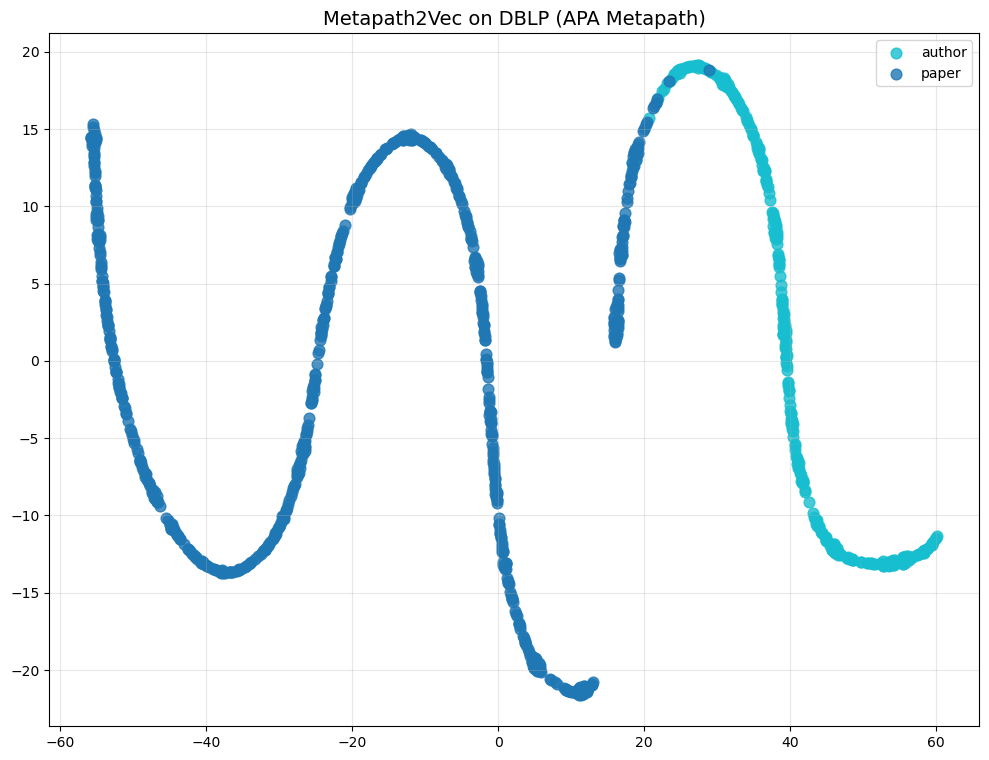

In [53]:
def visualize_embeddings(model, graph, title="Metapath2Vec Embeddings"):
    # Get embeddings for all nodes that exist in vocabulary
    nodes = []
    embeddings = []
    node_types = []
    
    for node in graph.nodes():
        node_str = str(node)
        if node_str in model.word2index:
            nodes.append(node)
            embeddings.append(model.syn0[model.word2index[node_str]])
            node_types.append(graph.nodes[node]['type'])
    
    embeddings = np.array(embeddings)
    
    # t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings)-1))
    emb_2d = tsne.fit_transform(embeddings)
    
    # Plot
    plt.figure(figsize=(12, 9))
    unique_types = list(set(node_types))
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_types)))
    color_map = {t: c for t, c in zip(unique_types, colors)}
    
    for i, node_type in enumerate(node_types):
        plt.scatter(emb_2d[i, 0], emb_2d[i, 1], 
                   color=color_map[node_type], s=60, alpha=0.8, 
                   label=node_type if i == 0 or node_type not in plt.gca().get_legend_handles_labels()[1] else "")
    
    plt.title(title, fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return embeddings

# Run visualization
embeddings = visualize_embeddings(model_dblp, dataset, 
                                 "Metapath2Vec on DBLP (APA Metapath)")

## 1.5. Node Clustering

In [55]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder

# Prepare labels
node_list = []
node_labels = []
embed_list = []

for node in dataset.nodes():
    node_str = str(node)
    if node_str in model_dblp.word2index:
        node_list.append(node)
        node_labels.append(dataset.nodes[node]['type'])
        embed_list.append(model_dblp.syn0[model_dblp.word2index[node_str]])

embed_array = np.array(embed_list)
label_encoder = LabelEncoder()
numeric_labels = label_encoder.fit_transform(node_labels)

sil_score = silhouette_score(embed_array, numeric_labels)
print(f"Silhouette Score: {sil_score:.4f}")

# Higher score = better separation between 'author' and 'paper' nodes

Silhouette Score: 0.7752


# 2. HIN2Vec: Explore Meta-paths in Heterogeneous Information Networks for Representation Learning

In [27]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
from itertools import product
import random
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
from sklearn.manifold import TSNE

# Random seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## 2.1. HIN model
**HIN** (Heterogeneous Information Network) is a directed graph $G = (V, E, \Phi, \Psi)$ where:

- $V$: set of nodes
- $E$: set of edges  
- $\Phi: V \rightarrow \mathcal{A}$: mapping from nodes to node types
- $\Psi: E \rightarrow \mathcal{R}$: mapping from edges to relation types
- Condition: $|\mathcal{A}| + |\mathcal{R}| > 2$ (there must be at least two different node types or relation types)

HIN2Vec learns embedding vectors for both **nodes** and **meta-paths** through the following process:

1. **Generate directed random walks** guided by meta-paths on the HIN.
2. **Define a prediction task:** Given a pair of nodes $(v_i, v_j)$ and a meta-path $\mathcal{P}$, predict whether $v_j$ is reachable from $v_i$ via $\mathcal{P}$.
3. **Prediction function:** 
   $$
   f(v_i, v_j, \mathcal{P}) = \sigma(\mathbf{x}_i \odot \mathbf{x}_j \odot \mathbf{r}_\mathcal{P}) \cdot \mathbf{w}
   $$
   - $\mathbf{x}_i, \mathbf{x}_j$: embedding vectors of nodes $i$ and $j$
   - $\mathbf{r}_\mathcal{P}$: embedding vector of meta-path $\mathcal{P}$
   - $\odot$: Hadamard product (element-wise multiplication)


In [39]:
class HeterogeneousInformationNetwork:

    def __init__(self):
        self.graph = nx.DiGraph()
        self.node_type = {}           # node_id -> type string
        self.edge_type = {}           # (u, v) -> relation string
        self.type_to_nodes = defaultdict(list)  # type -> list of node_ids
        self.node_id_counter = 0
        self.node_label = {}          # node_id -> label (author)
        
    def add_node(self, node_id, node_type, label=None):
        """Add nodes to HIN"""
        self.graph.add_node(node_id)
        self.node_type[node_id] = node_type
        self.type_to_nodes[node_type].append(node_id)
        if label is not None:
            self.node_label[node_id] = label
    
    def add_edge(self, u, v, relation):
        """Add edge to HIN"""
        self.graph.add_edge(u, v)
        self.edge_type[(u, v)] = relation
        # Add reverse edge (undirected HIN)
        self.graph.add_edge(v, u)
        self.edge_type[(v, u)] = relation + '_inv'
    
    def get_neighbors_by_type(self, node, target_type):
        """Take a node and return its neighbors of a specific type"""
        neighbors = []
        for nb in self.graph.neighbors(node):
            if self.node_type[nb] == target_type:
                neighbors.append(nb)
        return neighbors
    
    def get_schema(self):
        """Print out network schema"""
        print("=== Network Schema ===")
        print(f"Node types: {list(self.type_to_nodes.keys())}")
        print(f"Node counts: { {k: len(v) for k, v in self.type_to_nodes.items()} }")
        relation_types = set(self.edge_type.values())
        print(f"Relation types: {[r for r in relation_types if not r.endswith('_inv')]}")
        print(f"Total nodes: {self.graph.number_of_nodes()}")
        print(f"Total edges: {self.graph.number_of_edges() // 2} (bidirectional)")

## 2.2. Create small DBLP dataset

In [40]:
def create_dblp_hin():
    """
    Create small synthetic DBLP HIN with 4 research groups (40 authors), 8 conferences, 20 terms, and papers connecting them:
    - Group 0: Database (DB)
    - Group 1: Data Mining (DM) 
    - Group 2: Machine Learning (ML)
    - Group 3: Information Retrieval (IR)
    """
    hin = HeterogeneousInformationNetwork()
    
    # --- Create Authors (4 groups, 10 authors each) ---
    research_areas = ['Database', 'DataMining', 'MachineLearning', 'InfoRetrieval']
    authors_per_group = 10
    author_ids = []
    for g, area in enumerate(research_areas):
        for i in range(authors_per_group):
            a_id = f'A{g*authors_per_group + i}'
            hin.add_node(a_id, 'A', label=g)
            author_ids.append((a_id, g))
    
    # --- Create Conferences (8 conferences, 2 for each research area) ---
    conferences = [
        ('C0', 'VLDB'), ('C1', 'SIGMOD'),    # Database
        ('C2', 'KDD'),  ('C3', 'ICDM'),      # Data Mining
        ('C4', 'ICML'), ('C5', 'NeurIPS'),   # Machine Learning
        ('C6', 'SIGIR'), ('C7', 'ECIR'),     # Info Retrieval
    ]
    conf_to_area = {c_id: i//2 for i, (c_id, _) in enumerate(conferences)}
    for c_id, c_name in conferences:
        hin.add_node(c_id, 'C')
    
    # --- Create Terms (20 terms, 5 for each research area) ---
    terms = [
        'query', 'index', 'transaction', 'schema', 'sql',           # DB
        'clustering', 'classification', 'association', 'pattern', 'frequent',  # DM
        'neural', 'gradient', 'optimization', 'regression', 'bayesian',       # ML
        'retrieval', 'ranking', 'relevance', 'document', 'query_expansion',   # IR
    ]
    term_to_area = {f'T{i}': i//5 for i in range(20)}
    for i, t in enumerate(terms):
        hin.add_node(f'T{i}', 'T')
    
    # --- Create Papers and connect them ---
    paper_count = 0
    np.random.seed(SEED)
    
    for g in range(4):  # Each research group
        group_authors = [a_id for a_id, ga in author_ids if ga == g]
        group_confs = [c_id for c_id, _ in conferences if conf_to_area[c_id] == g]
        group_terms = [f'T{i}' for i in range(g*5, (g+1)*5)]
        
        # Each author writes 2-4 papers
        for author in group_authors:
            n_papers = np.random.randint(2, 5)
            for _ in range(n_papers):
                p_id = f'P{paper_count}'
                hin.add_node(p_id, 'P')
                
                # Connect author -> paper
                hin.add_edge(author, p_id, 'writes')
                
                # Add co-author (50% chance)
                if np.random.random() > 0.5:
                    co_author = np.random.choice(group_authors)
                    if co_author != author:
                        hin.add_edge(co_author, p_id, 'writes')
                
                # Occasionally collaborate across research areas (10%)
                if np.random.random() < 0.1:
                    other_group = np.random.choice([x for x in range(4) if x != g])
                    other_authors = [a_id for a_id, ga in author_ids if ga == other_group]
                    cross_author = np.random.choice(other_authors)
                    hin.add_edge(cross_author, p_id, 'writes')
                
                # Connect paper -> conference
                conf = np.random.choice(group_confs)
                hin.add_edge(p_id, conf, 'published_at')
                
                # Connect paper -> terms (2-3 terms)
                n_terms = np.random.randint(2, 4)
                selected_terms = np.random.choice(group_terms, n_terms, replace=False)
                for term in selected_terms:
                    hin.add_edge(p_id, term, 'contains')
                
                paper_count += 1
    
    return hin

# Create HIN
hin = create_dblp_hin()
hin.get_schema()

=== Network Schema ===
Node types: ['A', 'C', 'T', 'P']
Node counts: {'A': 40, 'C': 8, 'T': 20, 'P': 118}
Relation types: ['published_at', 'contains', 'writes']
Total nodes: 186
Total edges: 605 (bidirectional)


## 2.3. Visualize dataset

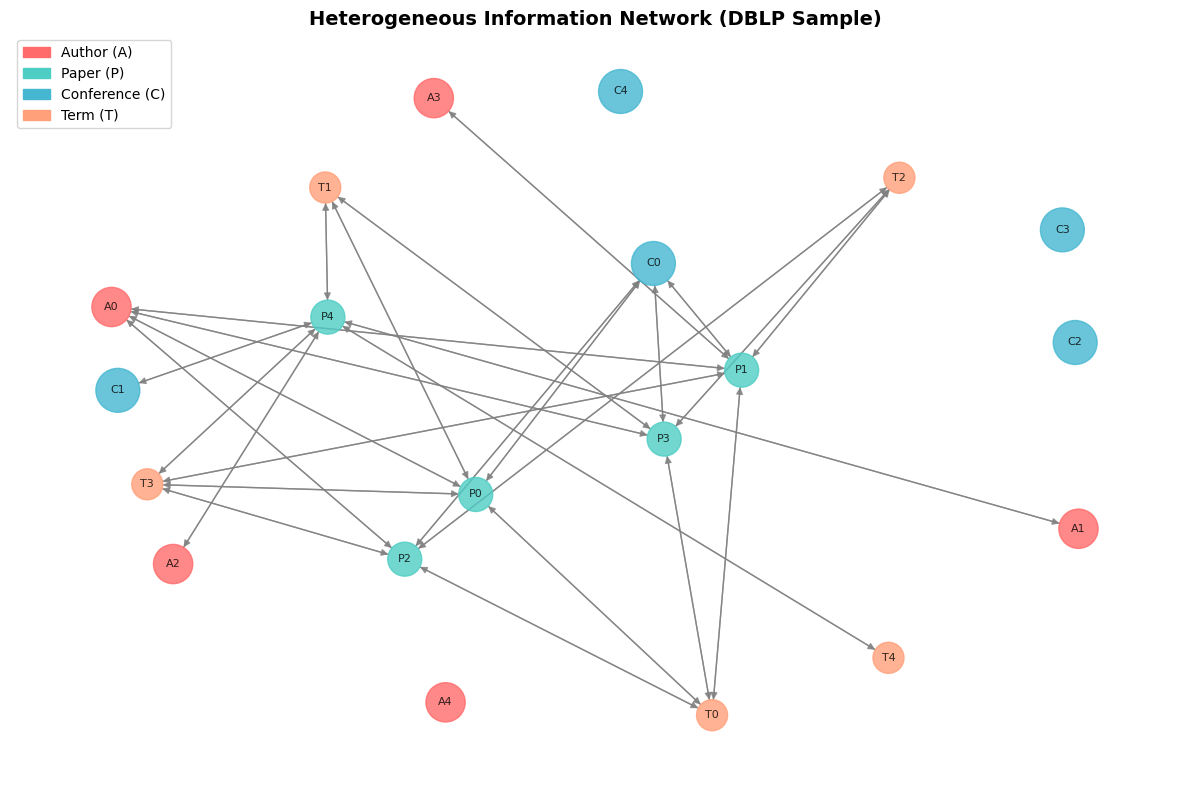

In [29]:
def visualize_hin_sample(hin, n_nodes_per_type=5):
    """Visualize a small portion of the HIN"""
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Get a sample of nodes to display
    sample_nodes = []
    for ntype, nodes in hin.type_to_nodes.items():
        sample_nodes.extend(nodes[:n_nodes_per_type])
    
    subgraph = hin.graph.subgraph(sample_nodes)
    
    # Color map for node types
    color_map = {'A': '#FF6B6B', 'P': '#4ECDC4', 'C': '#45B7D1', 'T': '#FFA07A'}
    node_colors = [color_map[hin.node_type[n]] for n in subgraph.nodes()]
    
    # Node sizes
    size_map = {'A': 800, 'P': 600, 'C': 1000, 'T': 500}
    node_sizes = [size_map[hin.node_type[n]] for n in subgraph.nodes()]
    
    pos = nx.spring_layout(subgraph, seed=SEED, k=2)
    nx.draw(subgraph, pos, ax=ax,
            node_color=node_colors,
            node_size=node_sizes,
            labels={n: n for n in subgraph.nodes()},
            font_size=8, arrows=True, arrowsize=10,
            edge_color='gray', alpha=0.8)
    
    # Legend
    legend_patches = [
        mpatches.Patch(color='#FF6B6B', label='Author (A)'),
        mpatches.Patch(color='#4ECDC4', label='Paper (P)'),
        mpatches.Patch(color='#45B7D1', label='Conference (C)'),
        mpatches.Patch(color='#FFA07A', label='Term (T)'),
    ]
    ax.legend(handles=legend_patches, loc='upper left', fontsize=10)
    ax.set_title('Heterogeneous Information Network (DBLP Sample)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_hin_sample(hin)

## 2.4. Define meta-paths

In DBLP dataset, some popular meta-path:

| Meta-path | Short | Meaning |
|-----------|---------|----------|
| Author-Paper-Author | APA | Two authors write a paper |
| Author-Paper-Conference-Paper-Author | APCPA | Authors at the same conference |
| Author-Paper-Term-Paper-Author | APTPA | Authors with the same term |

In [30]:
# Define meta-paths
META_PATHS = {
    'APA':   ['A', 'P', 'A'],
    'APCPA': ['A', 'P', 'C', 'P', 'A'],
    'APTPA': ['A', 'P', 'T', 'P', 'A'],
    'APAPA': ['A', 'P', 'A', 'P', 'A'],
}

print("Meta-paths:")
for name, path in META_PATHS.items():
    arrow_path = ' → '.join(path)
    print(f"  {name}: {arrow_path}")

Meta-paths:
  APA: A → P → A
  APCPA: A → P → C → P → A
  APTPA: A → P → T → P → A
  APAPA: A → P → A → P → A


## 2.5. Random walk with meta-path

In [31]:
def metapath_random_walk(hin, start_node, meta_path, walk_length):
    """
    Do random walk along a meta-path.
    
    Args:
        hin: Heterogeneous Information Network
        start_node: Starting node for the walk (must match the first type in meta-path)
        meta_path: List of node types in the meta-path (e.g., ['A', 'P', 'A'])
        walk_length: Maximum number of steps
    
    Returns:
        walk: List of nodes in the random walk
    """
    walk = [start_node]
    current = start_node
    path_len = len(meta_path)
    
    for step in range(walk_length - 1):
        # Determine the next node type based on the meta-path
        current_type_idx = step % (path_len - 1)
        next_type = meta_path[current_type_idx + 1]
        
        # Find neighbors of the correct node type
        candidates = hin.get_neighbors_by_type(current, next_type)
        
        if not candidates:
            break  # No further path available
        
        # Choose a neighbor at random
        next_node = random.choice(candidates)
        walk.append(next_node)
        current = next_node
    
    return walk


def generate_all_walks(hin, meta_path, n_walks=10, walk_length=50):
    """
    Create all random walks along a meta-path.
    
    Args:
        hin: HIN
        meta_path: Meta-path (list of node types)
        n_walks: Number of walks for each starting node
        walk_length: Length of each walk
    
    Returns:
        all_walks: List of all generated walks
    """
    start_type = meta_path[0]
    start_nodes = hin.type_to_nodes[start_type]
    all_walks = []
    
    for node in start_nodes:
        for _ in range(n_walks):
            walk = metapath_random_walk(hin, node, meta_path, walk_length)
            if len(walk) > 1:  # Only keep walks with at least 2 nodes
                all_walks.append(walk)
    
    return all_walks


# random walk
print("=== Example Random Walk following meta-path APA ===")
sample_author = hin.type_to_nodes['A'][0]
walk = metapath_random_walk(hin, sample_author, META_PATHS['APA'], walk_length=10)
print(f"Start: {sample_author} (type: {hin.node_type[sample_author]})")
print(f"Walk: {' -> '.join(walk)}")
print(f"Types: {' -> '.join([hin.node_type[n] for n in walk])}")
print()

print("=== Example Random Walk following meta-path APCPA ===")
walk2 = metapath_random_walk(hin, sample_author, META_PATHS['APCPA'], walk_length=10)
print(f"Walk: {' -> '.join(walk2)}")
print(f"Types: {' -> '.join([hin.node_type[n] for n in walk2])}")

=== Example Random Walk following meta-path APA ===
Start: A0 (type: A)
Walk: A0 -> P11 -> A3 -> P1 -> A3 -> P10 -> A3 -> P10 -> A17 -> P10
Types: A -> P -> A -> P -> A -> P -> A -> P -> A -> P

=== Example Random Walk following meta-path APCPA ===
Walk: A0 -> P11 -> C1 -> P23 -> A7 -> P0 -> C0 -> P3 -> A0 -> P10
Types: A -> P -> C -> P -> A -> P -> C -> P -> A -> P


## 2.6. Create pairs

In [32]:
def generate_training_pairs(walks, window_size=3):
    """
    Create pairs (node_i, node_j) from the list of walks.
    Two nodes form a positive pair if they are within the window.
    
    Args:
        walks: List of random walks
        window_size: Size of the context window
    
    Returns:
        pairs: List of pairs (node_i, node_j)
    """
    pairs = []
    for walk in walks:
        for i, center in enumerate(walk):
            for j in range(max(0, i - window_size), min(len(walk), i + window_size + 1)):
                if i != j:
                    pairs.append((center, walk[j]))
    return pairs


# Create walks and training pairs for each meta-path
print("Creating random walks...")
all_walks_per_metapath = {}
all_pairs_per_metapath = {}

for mp_name, mp_path in META_PATHS.items():
    walks = generate_all_walks(hin, mp_path, n_walks=5, walk_length=30)
    pairs = generate_training_pairs(walks, window_size=2)
    all_walks_per_metapath[mp_name] = walks
    all_pairs_per_metapath[mp_name] = pairs
    print(f"  {mp_name}: {len(walks)} walks, {len(pairs)} training pairs")

print("\nCompleted creating training data!")

Creating random walks...
  APA: 200 walks, 22800 training pairs
  APCPA: 200 walks, 22800 training pairs
  APTPA: 200 walks, 22800 training pairs
  APAPA: 200 walks, 22800 training pairs

Completed creating training data!


## 2.7. Map node ID

In [33]:
class NodeIndexer:
    """Map node_id (string) to index (integer) for embedding layer"""
    def __init__(self, hin):
        all_nodes = list(hin.graph.nodes())
        self.node2idx = {n: i for i, n in enumerate(all_nodes)}
        self.idx2node = {i: n for i, n in enumerate(all_nodes)}
        self.n_nodes = len(all_nodes)
        
        # Map meta-path name to index
        mp_names = list(META_PATHS.keys())
        self.mp2idx = {mp: i for i, mp in enumerate(mp_names)}
        self.n_metapaths = len(mp_names)
    
    def encode_node(self, node_id):
        return self.node2idx[node_id]
    
    def encode_metapath(self, mp_name):
        return self.mp2idx[mp_name]

indexer = NodeIndexer(hin)
print(f"Total nodes: {indexer.n_nodes}")
print(f"Total meta-paths: {indexer.n_metapaths}")
print(f"Sample: node 'A0' -> index {indexer.encode_node('A0')}")

Total nodes: 186
Total meta-paths: 4
Sample: node 'A0' -> index 0


## 2.8. HIN2Vec

In [34]:
class HIN2Vec(nn.Module):
    """
    Learning simultaneously:
    - Node embeddings: X ∈ R^(n_nodes × dim)
    - Meta-path embeddings: R ∈ R^(n_metapaths × dim)
    """
    def __init__(self, n_nodes, n_metapaths, embed_dim=64):
        super(HIN2Vec, self).__init__()
        self.embed_dim = embed_dim
        
        # Node embeddings
        self.node_embed = nn.Embedding(n_nodes, embed_dim)
        
        # Meta-path embeddings (with L2 regularization)
        self.mp_embed = nn.Embedding(n_metapaths, embed_dim)
        
        # Output weight vector
        self.output_layer = nn.Linear(embed_dim, 1, bias=False)
        
        # Initialize weights
        nn.init.xavier_uniform_(self.node_embed.weight)
        nn.init.xavier_uniform_(self.mp_embed.weight)
        nn.init.xavier_uniform_(self.output_layer.weight)
    
    def forward(self, node_i, node_j, metapath_idx):
        """
        Args:
            node_i: (batch_size,) - index of source node
            node_j: (batch_size,) - index of target node
            metapath_idx: (batch_size,) - index of meta-path

        Returns:
            prob: (batch_size,) - probability of relation existence
        """
        # Lấy embeddings
        x_i = self.node_embed(node_i)      # (batch, dim)
        x_j = self.node_embed(node_j)      # (batch, dim)
        r_p = self.mp_embed(metapath_idx)  # (batch, dim)
        
        # Hadamard product + tanh
        combined = x_i * x_j * r_p        # element-wise multiply
        combined = torch.tanh(combined)    # activation
        
        # Output
        logit = self.output_layer(combined).squeeze(-1)  # (batch,)
        return logit
    
    def get_node_embeddings(self):
        """Return node embeddings (detach from computation graph)"""
        return self.node_embed.weight.detach().cpu().numpy()
    
    def get_metapath_embeddings(self):
        """Return meta-path embeddings"""
        return self.mp_embed.weight.detach().cpu().numpy()


# Create model
EMBED_DIM = 64
model = HIN2Vec(
    n_nodes=indexer.n_nodes,
    n_metapaths=indexer.n_metapaths,
    embed_dim=EMBED_DIM
)

print("=== Model Architecture: HIN2Vec ===")
print(model)
print(f"\nTotal Parameters: {sum(p.numel() for p in model.parameters()):,}")

=== Model Architecture: HIN2Vec ===
HIN2Vec(
  (node_embed): Embedding(186, 64)
  (mp_embed): Embedding(4, 64)
  (output_layer): Linear(in_features=64, out_features=1, bias=False)
)

Total Parameters: 12,224


## 2.9. Apply negative sampling

In [35]:
class HIN2VecDataset(Dataset):
    """
    Dataset for HIN2Vec with negative sampling based on node types.
    """
    def __init__(self, hin, indexer, all_pairs_per_metapath, n_negative=5):
        """
        Args:
            hin: HIN object
            indexer: NodeIndexer
            all_pairs_per_metapath: dict {mp_name: [(node_i, node_j), ...]}
            n_negative: Number of negative samples for each positive sample
        """
        self.hin = hin
        self.indexer = indexer
        self.n_negative = n_negative
        
        # Create training samples: (node_i_idx, node_j_idx, mp_idx, label)
        self.samples = []
        
        for mp_name, pairs in all_pairs_per_metapath.items():
            mp_idx = indexer.encode_metapath(mp_name)
            mp_path = META_PATHS[mp_name]
            # Determine target node type based on the last type in the meta-path
            target_type = mp_path[-1]
            target_nodes = hin.type_to_nodes[target_type]
            
            for (ni, nj) in pairs:
                ni_idx = indexer.encode_node(ni)
                nj_idx = indexer.encode_node(nj)
                
                # Positive sample
                self.samples.append((ni_idx, nj_idx, mp_idx, 1.0))
                
                # Negative samples
                for _ in range(n_negative):
                    neg_node = random.choice(target_nodes)
                    while neg_node == nj:  # Avoid sampling the positive node as negative
                        neg_node = random.choice(target_nodes)
                    neg_idx = indexer.encode_node(neg_node)
                    self.samples.append((ni_idx, neg_idx, mp_idx, 0.0))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        ni_idx, nj_idx, mp_idx, label = self.samples[idx]
        return (
            torch.tensor(ni_idx, dtype=torch.long),
            torch.tensor(nj_idx, dtype=torch.long),
            torch.tensor(mp_idx, dtype=torch.long),
            torch.tensor(label, dtype=torch.float)
        )


# Create Dataset and DataLoader
dataset = HIN2VecDataset(hin, indexer, all_pairs_per_metapath, n_negative=5)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

print(f"Dataset size: {len(dataset):,} samples")
print(f"Number of batches: {len(dataloader)}")

# View a batch
batch_ni, batch_nj, batch_mp, batch_label = next(iter(dataloader))
print(f"\nShape of the batch:")
print(f"  node_i: {batch_ni.shape}")
print(f"  node_j: {batch_nj.shape}")
print(f"  metapath: {batch_mp.shape}")
print(f"  label: {batch_label.shape}")
print(f"  Positive ratio: {batch_label.mean():.3f} (Ideal: {1/(1+5):.3f})")

Dataset size: 547,200 samples
Number of batches: 2138

Shape of the batch:
  node_i: torch.Size([256])
  node_j: torch.Size([256])
  metapath: torch.Size([256])
  label: torch.Size([256])
  Positive ratio: 0.191 (Ideal: 0.167)


## 2.10. Train

In [37]:
def train_hin2vec(model, dataloader, n_epochs=30, lr=0.01, weight_decay=1e-4, device=None):
    """
    Train HIN2Vec.
    
    Loss function: Binary Cross Entropy (with negative sampling)
    $L = -\sum [y \log \hat{y} + (1-y) \log(1-\hat{y})]$
    
    Args:
        model: HIN2Vec model
        dataloader: Training data loader
        n_epochs: Number of epochs
        lr: Learning rate
        weight_decay: Weight decay for regularization
        
    """
    # Auto-detect device if not specified
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    print(f"Training on device: {device}")
    
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()
    
    history = {'loss': [], 'epoch': []}
    
    model.train()
    for epoch in range(n_epochs):
        total_loss = 0.0
        n_batches = 0
        
        for batch_ni, batch_nj, batch_mp, batch_label in dataloader:
            # Move batch to device
            batch_ni = batch_ni.to(device)
            batch_nj = batch_nj.to(device)
            batch_mp = batch_mp.to(device)
            batch_label = batch_label.to(device)
            
            optimizer.zero_grad()
            
            # Forward pass
            logits = model(batch_ni, batch_nj, batch_mp)
            
            # Calculate loss
            loss = criterion(logits, batch_label)
            
            # Backward pass
            loss.backward()
            
            # Gradient clipping (to prevent exploding gradients)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            # Regularize meta-path embeddings (L2 normalize)
            with torch.no_grad():
                mp_norm = model.mp_embed.weight.norm(dim=1, keepdim=True)
                model.mp_embed.weight.data = model.mp_embed.weight.data / (mp_norm + 1e-8)
            
            total_loss += loss.item()
            n_batches += 1
        
        avg_loss = total_loss / n_batches
        history['loss'].append(avg_loss)
        history['epoch'].append(epoch + 1)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1:3d}/{n_epochs}] | Loss: {avg_loss:.4f}")
    
    return history


print("Starting HIN2Vec training...\n")
history = train_hin2vec(model, dataloader, n_epochs=30, lr=0.01)
print("\n✅ Training completed!")

Starting HIN2Vec training...

Training on device: cuda
Epoch [  5/30] | Loss: 0.1571
Epoch [ 10/30] | Loss: 0.1549
Epoch [ 15/30] | Loss: 0.1540
Epoch [ 20/30] | Loss: 0.1535
Epoch [ 25/30] | Loss: 0.1531
Epoch [ 30/30] | Loss: 0.1528

✅ Training completed!


## 2.11. Loss Visualization

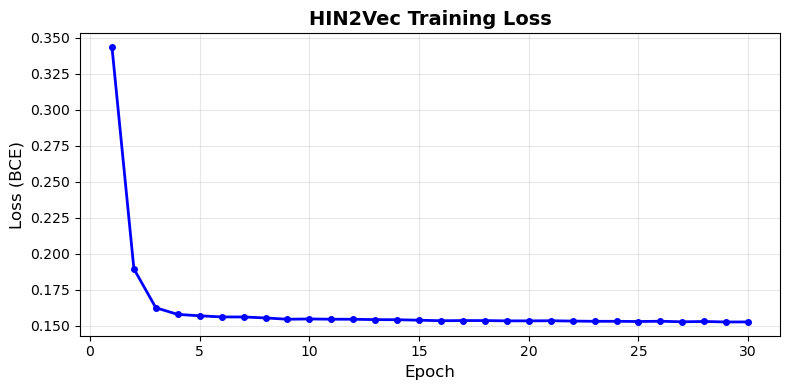

Final loss: 0.1528


In [38]:
plt.figure(figsize=(8, 4))
plt.plot(history['epoch'], history['loss'], 'b-o', markersize=4, linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (BCE)', fontsize=12)
plt.title('HIN2Vec Training Loss', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Final loss: {history['loss'][-1]:.4f}")

## 2.12. Evaluation

In [41]:
def evaluate_node_classification(model, hin, indexer):
    """
    Evaluate node embeddings on Author classification task (predict research area).
    """
    model.eval()
    
    # Take node embeddings
    all_embeddings = model.get_node_embeddings()
    
    # Prepare features and labels for Authors
    X, y = [], []
    for author in hin.type_to_nodes['A']:
        if author in hin.node_label:
            idx = indexer.encode_node(author)
            X.append(all_embeddings[idx])
            y.append(hin.node_label[author])
    
    X = np.array(X)
    y = np.array(y)
    
    print(f"Evaluation data: {len(X)} authors, {len(set(y))} classes")
    
    # Train/test split
    results = {}
    for train_ratio in [0.3, 0.5, 0.7]:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, train_size=train_ratio, random_state=SEED, stratify=y
        )
        
        # Logistic Regression classifier
        clf = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        
        macro_f1 = f1_score(y_test, y_pred, average='macro')
        micro_f1 = f1_score(y_test, y_pred, average='micro')
        acc = accuracy_score(y_test, y_pred)
        
        results[train_ratio] = {'macro_f1': macro_f1, 'micro_f1': micro_f1, 'acc': acc}
        print(f"  Train {int(train_ratio*100)}% | Acc: {acc:.4f} | Macro-F1: {macro_f1:.4f} | Micro-F1: {micro_f1:.4f}")
    
    return X, y, results


print("=== Node Classification (Author Research Area) ===")
embeddings_2d, labels, eval_results = evaluate_node_classification(model, hin, indexer)

=== Node Classification (Author Research Area) ===
Evaluation data: 40 authors, 4 classes
  Train 30% | Acc: 0.7500 | Macro-F1: 0.7475 | Micro-F1: 0.7500
  Train 50% | Acc: 0.7500 | Macro-F1: 0.7374 | Micro-F1: 0.7500
  Train 70% | Acc: 0.8333 | Macro-F1: 0.8036 | Micro-F1: 0.8333


## 2.13. Visualize meta-path embeddings

=== Meta-path Embeddings ===
Shape: (4, 64)



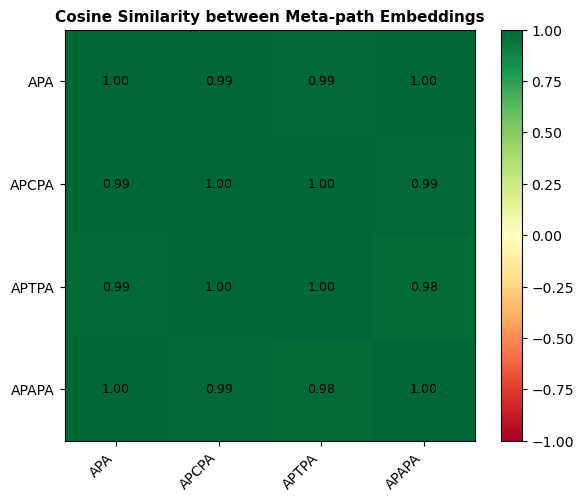

In [43]:
mp_embeddings = model.get_metapath_embeddings()
mp_names = list(META_PATHS.keys())

print("=== Meta-path Embeddings ===")
print(f"Shape: {mp_embeddings.shape}")
print()

# Calculate cosine similarity between meta-paths
from sklearn.metrics.pairwise import cosine_similarity
mp_sim = cosine_similarity(mp_embeddings)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(mp_sim, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(mp_names)))
ax.set_yticks(range(len(mp_names)))
ax.set_xticklabels(mp_names, rotation=45, ha='right')
ax.set_yticklabels(mp_names)
plt.colorbar(im, ax=ax)
ax.set_title('Cosine Similarity between Meta-path Embeddings', fontsize=11, fontweight='bold')

for i in range(len(mp_names)):
    for j in range(len(mp_names)):
        ax.text(j, i, f'{mp_sim[i,j]:.2f}', ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# 3. Are Meta-Paths Necessary?: Revisiting Heterogeneous Graph Embeddings (JUST)

## 3.1. Word2Vec

In [69]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import math
from collections import defaultdict
from tqdm import tqdm
import numpy as np
from sklearn.manifold import TSNE

class Word2Vec:
    def __init__(self, vector_size=64, window=5, negative=5, alpha=0.01, min_count=1, epochs=4):
        self.vector_size = vector_size
        self.window = window
        self.negative = negative
        self.alpha = alpha
        self.min_count = min_count
        self.epochs = epochs
        
        self.index2word = []
        self.word2index = {}
        self.syn0 = None
        self.syn1neg = None
        
    def build_vocab(self, sentences):
        word_count = {}
        for sentence in sentences:
            for word in sentence:
                word_count[word] = word_count.get(word, 0) + 1
        self.index2word = [word for word, cnt in word_count.items() if cnt >= self.min_count]
        self.word2index = {word: i for i, word in enumerate(self.index2word)}
        print(f"Vocabulary size: {len(self.index2word)}")
        
    def init_weights(self):
        vocab_size = len(self.index2word)
        self.syn0 = np.random.uniform(-0.5/self.vector_size, 0.5/self.vector_size, 
                                     (vocab_size, self.vector_size)).astype(np.float32)
        self.syn1neg = np.zeros((vocab_size, self.vector_size), dtype=np.float32)
        
    def train(self, sentences):
        self.build_vocab(sentences)
        self.init_weights()
        for epoch in range(self.epochs):
            print(f"Epoch {epoch+1}/{self.epochs}")
            self._train_epoch(sentences)
    
    def _train_epoch(self, sentences):
        for sentence in tqdm(sentences, desc="Training"):
            for i, word in enumerate(sentence):
                if word not in self.word2index: continue
                word_idx = self.word2index[word]
                start = max(0, i - self.window)
                end = min(len(sentence), i + self.window + 1)
                for j in range(start, end):
                    if j != i and sentence[j] in self.word2index:
                        context_idx = self.word2index[sentence[j]]
                        self._train_pair(word_idx, context_idx)
    
    def _stable_sigmoid(self, x):
        x = np.clip(x, -10, 10)
        return 1 / (1 + np.exp(-x))
    
    def _train_pair(self, word_idx, context_idx):
        vector = self.syn0[word_idx]
        label_vec = self.syn1neg[context_idx]
        
        dot = np.dot(vector, label_vec)
        sigmoid = self._stable_sigmoid(dot)
        grad = self.alpha * (1 - sigmoid)
        
        self.syn0[word_idx] += grad * label_vec
        self.syn1neg[context_idx] += grad * vector
        
        for _ in range(self.negative):
            neg_idx = random.randint(0, len(self.index2word)-1)
            if neg_idx == context_idx: continue
            neg_vec = self.syn1neg[neg_idx]
            dot_neg = np.dot(vector, neg_vec)
            sigmoid_neg = self._stable_sigmoid(dot_neg)
            grad_neg = self.alpha * (0 - sigmoid_neg)
            
            self.syn0[word_idx] += grad_neg * neg_vec
            self.syn1neg[neg_idx] += grad_neg * vector

    def get_embeddings(self):
        embeddings = {word: self.syn0[idx].copy() for word, idx in self.word2index.items()}
        # Clean NaNs
        for word, emb in embeddings.items():
            if np.isnan(emb).any():
                embeddings[word] = np.zeros(self.vector_size, dtype=np.float32)
        return embeddings

## 3.2. JUST model

**JUST** (JUmp and STay) is a heterogeneous graph embedding technique that does **not** rely on meta-paths. It uses biased random walks with dynamic "jump" and "stay" strategies to balance homogeneous and heterogeneous transitions.

### JUST Embedding Process
JUST learns node embeddings through the following steps:

1. **Generate random walks** guided by **JUmp** and **STay** strategies (no meta-paths required).
2. **Define a prediction task**: Use Skip-Gram with negative sampling on the generated walks (similar to Word2Vec).
3. **Key Idea**: At each step, the walker probabilistically decides whether to:
   - **Stay** in the current node type (homogeneous transition), or
   - **Jump** to a different node type (heterogeneous transition).

### Core Mechanism
The probability of staying decreases with the length of the current homogeneous sequence using an **exponential decay**:

$$
P(\text{heterogeneous}) = 1 - \alpha^{l}
$$

where:
- \( \alpha \): decay parameter (controls jump vs stay balance)
- \( l \): length of current homogeneous sequence

When jumping, JUST avoids recently visited node types (using a memory of last \( m \) domains) to better balance node type distribution.

In [57]:
def generate_node_types(node_types_file):
    heterg_dictionary = {}
    with open(node_types_file) as f:
        for line in f:
            if line.strip():
                node_type, hete_values = line.strip().split(":")
                heterg_dictionary[node_type] = hete_values.split(",")
    return heterg_dictionary


def random_walk_just(G, path_length, heterg_dictionary, alpha=0.5, start=None):
    if start is None:
        start = random.choice(list(G.nodes()))
    
    path = [start]
    homog_length = 1
    no_next = False

    while len(path) < path_length and not no_next:
        cur = path[-1]
        cur_type = G.nodes[cur]['type']
        heterg_types = heterg_dictionary.get(cur_type, [])

        heterg_prob = 1 - math.pow(alpha, homog_length)
        r = random.uniform(0, 1)

        candidates = []

        if r <= heterg_prob:  # Jump
            for ht in heterg_types:
                candidates.extend([n for n in G[cur] if G.nodes[n]['type'] == ht])
            if not candidates:
                candidates = [n for n in G[cur] if G.nodes[n]['type'] == cur_type]
        else:  # Stay
            candidates = [n for n in G[cur] if G.nodes[n]['type'] == cur_type]
            if not candidates:
                for ht in heterg_types:
                    candidates.extend([n for n in G[cur] if G.nodes[n]['type'] == ht])

        if not candidates:
            no_next = True
        else:
            next_node = random.choice(candidates)
            path.append(next_node)
            
            if G.nodes[next_node]['type'] == cur_type:
                homog_length += 1
            else:
                homog_length = 1
    return path


def generate_walks(G, num_walks, walk_length, heterg_dictionary, alpha=0.5):
    print("Generating random walks...")
    walks = []
    nodes = list(G.nodes())
    
    for _ in tqdm(range(num_walks)):
        random.shuffle(nodes)
        for node in nodes:
            walk = random_walk_just(G, walk_length, heterg_dictionary, alpha, node)
            walks.append([str(n) for n in walk])
    
    print(f"Generated {len(walks)} walks")
    return walks

## 3.3. Create DBLP-like dataset

In [58]:
def create_fake_dblp():
    G = nx.Graph()
    
    # Create nodes
    for i in range(40):   # Authors
        G.add_node(f'A{i}', type='A')
    for i in range(60):   # Papers
        G.add_node(f'P{i}', type='P')
    for i in range(50):   # Terms
        G.add_node(f'T{i}', type='T')
    for i in range(15):   # Conferences
        G.add_node(f'C{i}', type='C')
    
    nodes = list(G.nodes(data=True))
    
    # Add realistic edges
    random.seed(42)
    
    # Author - Paper
    for _ in range(180):
        a = random.choice([n for n,t in G.nodes(data=True) if t['type']=='A'])
        p = random.choice([n for n,t in G.nodes(data=True) if t['type']=='P'])
        G.add_edge(a, p)
    
    # Paper - Term
    for _ in range(220):
        p = random.choice([n for n,t in G.nodes(data=True) if t['type']=='P'])
        t = random.choice([n for n,t in G.nodes(data=True) if t['type']=='T'])
        G.add_edge(p, t)
    
    # Paper - Conference
    for _ in range(70):
        p = random.choice([n for n,t in G.nodes(data=True) if t['type']=='P'])
        c = random.choice([n for n,t in G.nodes(data=True) if t['type']=='C'])
        G.add_edge(p, c)
    
    print(f"Fake DBLP created: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    print("Node type distribution:")
    types = nx.get_node_attributes(G, 'type')
    for t in ['A','P','T','C']:
        count = list(types.values()).count(t)
        print(f"  {t}: {count}")
    
    return G

## 3.5. Train

In [64]:
# Create node types file
with open("dblp_node_types.txt", "w") as f:
    f.write("A:P,T,C\nP:A,T,C\nT:A,P\nC:P")

G = create_fake_dblp()
heterg_dict = generate_node_types("dblp_node_types.txt")

# Generate walks
walks = generate_walks(
    G=G, 
    num_walks=10, 
    walk_length=50, 
    heterg_dictionary=heterg_dict, 
    alpha=0.5
)

# Train embeddings
w2v = Word2Vec(vector_size=64, window=5, negative=5, alpha=0.025, epochs=4)
print("\nTraining Word2Vec on fake DBLP...")
w2v.train(walks)

embeddings = w2v.get_embeddings()
print("Training completed!")

Fake DBLP created: 165 nodes, 454 edges
Node type distribution:
  A: 40
  P: 60
  T: 50
  C: 15
Generating random walks...


  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 19.80it/s]


Generated 1650 walks

Training Word2Vec on fake DBLP...
Vocabulary size: 165
Epoch 1/4


Training: 100%|██████████| 1650/1650 [01:16<00:00, 21.54it/s]


...

Epoch 3/4


Training: 100%|██████████| 1650/1650 [01:16<00:00, 21.51it/s]


Epoch 4/4


Training: 100%|██████████| 1650/1650 [01:16<00:00, 21.46it/s]

Training completed!


## 3.6. Node clustering

=== JUST Embedding Evaluation on Fake DBLP ===
Silhouette Score (by node type): -0.0845 → Higher is better (max 1.0)
Cluster Purity: 0.4121 → Higher is better (max 1.0)


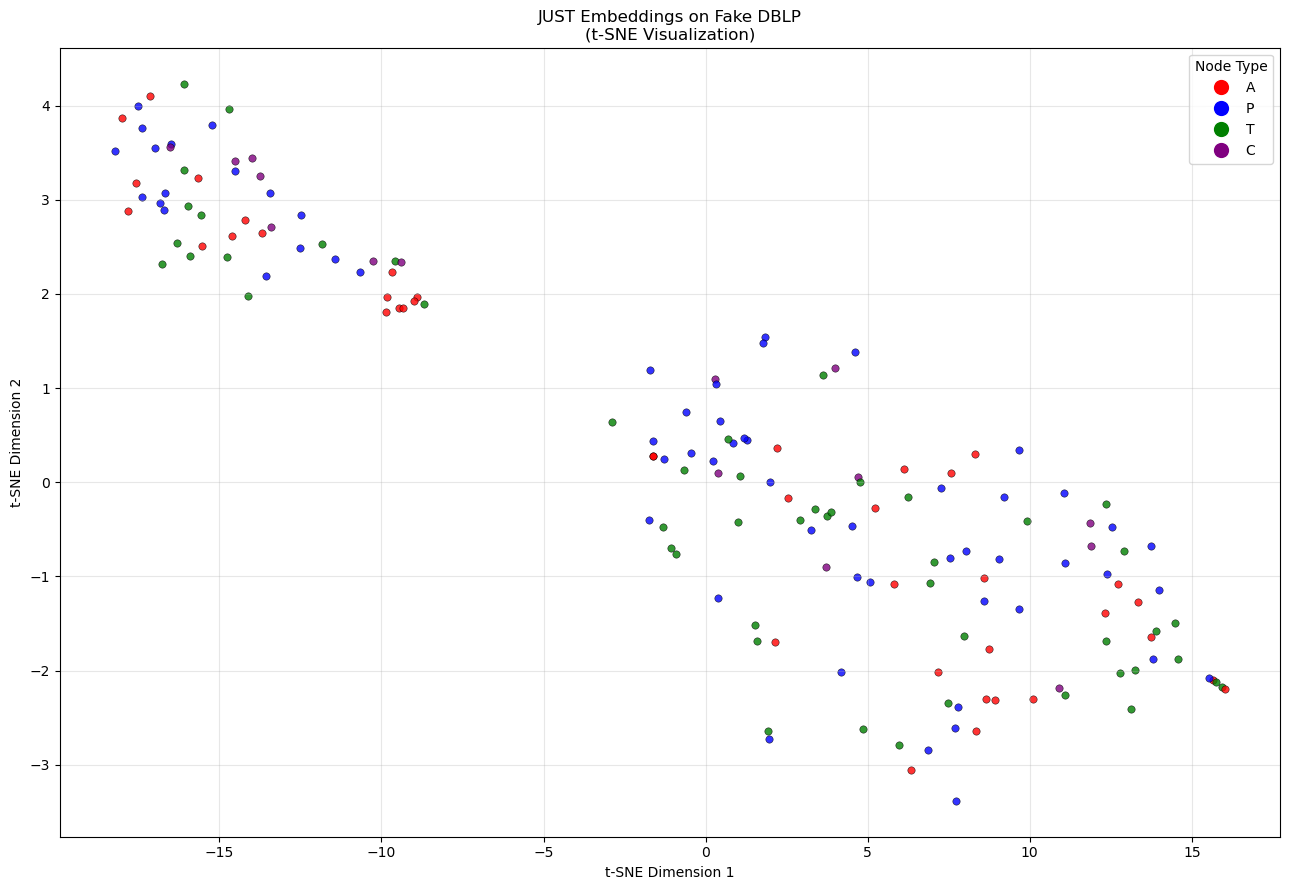

In [72]:
from sklearn.cluster import KMeans

def evaluate_embeddings(embeddings, G):
    nodes = list(embeddings.keys())
    X = np.array([embeddings[node] for node in nodes])
    X = np.nan_to_num(X, nan=0.0)
    
    node_types = [G.nodes[node]['type'] for node in nodes]
    type_to_int = {'A':0, 'P':1, 'T':2, 'C':3}
    labels = np.array([type_to_int[t] for t in node_types])
    
    print("=== JUST Embedding Evaluation on Fake DBLP ===")
    
    # 1. Silhouette Score
    if len(set(labels)) > 1:
        sil_score = silhouette_score(X, labels)
        print(f"Silhouette Score (by node type): {sil_score:.4f} → Higher is better (max 1.0)")
    else:
        sil_score = None
        print("Silhouette Score: Not applicable (only one class)")
    
    # 2. KMeans Cluster Purity
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
    pred_clusters = kmeans.fit_predict(X)
    
    from collections import Counter
    purity = 0
    for c in range(4):
        cluster_labels = labels[pred_clusters == c]
        if len(cluster_labels) > 0:
            most_common = Counter(cluster_labels).most_common(1)[0][0]
            purity += sum(cluster_labels == most_common)
    purity /= len(labels)
    print(f"Cluster Purity: {purity:.4f} → Higher is better (max 1.0)")
    
    # 3. Visualization with Fixed Legend
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
    X_2d = tsne.fit_transform(X)
    
    plt.figure(figsize=(13, 9))
    colors = {'A':'red', 'P':'blue', 'T':'green', 'C':'purple'}
    
    # Plot points
    for i, t in enumerate(node_types):
        plt.scatter(X_2d[i,0], X_2d[i,1], c=colors[t], alpha=0.8, s=28, 
                   edgecolors='black', linewidth=0.4)
    
    # Fixed Legend
    handles = [plt.Line2D([0], [0], marker='o', color='w', 
                         markerfacecolor=colors[t], markersize=12, label=t) 
              for t in colors.keys()]
    
    plt.legend(handles=handles, loc='best', title="Node Type")
    plt.title("JUST Embeddings on Fake DBLP\n(t-SNE Visualization)")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return sil_score


# === Run Evaluation ===
embeddings = w2v.get_embeddings()
score = evaluate_embeddings(embeddings, G)

# 4. BHIN2vec: Balancing the Type of Relation in Heterogeneous Information Network


In [73]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from collections import defaultdict
import random

torch.manual_seed(42)
np.random.seed(42)

## 4.1. Create fake dataset

In [77]:
def create_fake_dblp(num_authors=200, num_papers=500, num_venues=30, num_topics=80):
    G = nx.Graph()
    authors = [f'A{i}' for i in range(num_authors)]
    papers = [f'P{i}' for i in range(num_papers)]
    venues = [f'V{i}' for i in range(num_venues)]
    topics = [f'T{i}' for i in range(num_topics)]
    
    node_list = authors + papers + venues + topics
    node_type = {}
    for n in authors: node_type[n] = 'A'
    for n in papers: node_type[n] = 'P'
    for n in venues: node_type[n] = 'V'
    for n in topics: node_type[n] = 'T'
    
    G.add_nodes_from(node_list)
    nx.set_node_attributes(G, node_type, 'type')
    
    for p in papers:
        # Author -> Paper (write)
        for a in random.sample(authors, k=min(3, len(authors))):
            G.add_edge(a, p, type='write')
        # Paper -> Venue (publish)
        G.add_edge(p, random.choice(venues), type='publish')
        # Paper -> Topic (has_topic)
        G.add_edge(p, random.choice(topics), type='has_topic')
    
    print(f"Fake DBLP: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    return G, node_type

G, node_type_dict = create_fake_dblp()
node2idx = {node: i for i, node in enumerate(G.nodes())}
idx2node = {i: node for node, i in node2idx.items()}
node_types = list(set(node_type_dict.values()))  # ['A','P','V','T']
type2idx = {t: i for i, t in enumerate(node_types)}

Fake DBLP: 810 nodes, 2500 edges


## 4.2. BHIN2Vec

**BHIN2Vec** (Balanced Heterogeneous Information Network to Vector) is a heterogeneous network embedding method that addresses the **imbalance problem** among different relation types in HINs.

Unlike standard methods that are dominated by frequent relations, **BHIN2Vec** balances training across all relation types.

BHIN2Vec learns node embeddings through the following process:

1. **View heterogeneous embedding as multi-task learning** — each relation type (or node type pair) is treated as a separate task.
2. **Use a Balanced Skip-Gram model** with relationship embeddings that consider distance and source/target node types.
3. **Apply a biased random walk** guided by a **learnable stochastic transition matrix** updated via **inverse training ratio** (focusing more on under-trained / high-loss relations).

**Core Idea (Balancing Mechanism)**:  
After splitting the Skip-Gram loss into per-relation losses, BHIN2Vec dynamically adjusts the sampling probability of each relation type using the **inverse training ratio**. This ensures that rare or difficult relations receive sufficient training.

**Prediction Function (Balanced Skip-Gram)**:  
For a node \( v_i \), context node \( v_j \), and relation-aware context (distance + types):

$$
f(v_i, v_j, r) = \sigma \left( \mathbf{x}_i^\top (\mathbf{x}_j + \mathbf{r}_{d, t_i, t_j}) \right)
$$

- \( \mathbf{x}_i, \mathbf{x}_j \): node embedding vectors
- \( \mathbf{r}_{d, t_i, t_j} \): relationship embedding (distance \( d \), source type \( t_i \), target type \( t_j \))
- \( \sigma \): sigmoid function

In [81]:
class BalancedSkipGramModel(nn.Module):
    def __init__(self, node_num, type_num, dim=128, l=10, k=5, m=5):
        super().__init__()
        
        # Use nn.Embedding instead of nn.Parameter
        self.node_embedding = nn.Embedding(node_num, dim)
        self.relationship_embedding = nn.Embedding(k * type_num * type_num, dim)
        
        # Proper initialization
        nn.init.normal_(self.node_embedding.weight, std=0.1)
        nn.init.normal_(self.relationship_embedding.weight, std=0.1)
        
        self.dim = dim
        self.l = l
        self.k = k
        self.m = m
        self.type_num = type_num

    def forward(self, walk, pos, neg, walk_type, pos_type, neg_type):
        """
        walk:       [B, L-k]
        pos:        [B, L-k, k]
        neg:        [B, L-k, k, m]
        walk_type:  [B, L-k]
        pos_type:   [B, L-k, k]
        neg_type:   [B, L-k, k, m]
        """
        B = walk.shape[0]
        
        # Node embeddings
        walk_emb = self.node_embedding(walk)                    # [B, L-k, D]
        pos_emb = self.node_embedding(pos)                      # [B, L-k, k, D]
        neg_emb = self.node_embedding(neg)                      # [B, L-k, k, m, D]
        
        # Relationship type indices
        pos_pair_type = self.type_num * walk_type.unsqueeze(2) + pos_type          # [B, L-k, k]
        neg_pair_type = self.type_num * walk_type.unsqueeze(2).unsqueeze(3) + neg_type  # [B, L-k, k, m]
        
        # Relationship embeddings (distance + type aware)
        dist_idx = torch.arange(self.k, device=walk.device).unsqueeze(0).unsqueeze(0)   # [1, 1, k]
        rel_idx_pos = dist_idx * (self.type_num ** 2) + pos_pair_type                    # [B, L-k, k]
        rel_emb_pos = self.relationship_embedding(rel_idx_pos)                           # [B, L-k, k, D]
        
        dist_idx_neg = dist_idx.unsqueeze(3)                                              # [1, 1, k, 1]
        rel_idx_neg = dist_idx_neg * (self.type_num ** 2) + neg_pair_type
        rel_emb_neg = self.relationship_embedding(rel_idx_neg)                           # [B, L-k, k, m, D]
        
        # Compute scores: node + relation embedding
        pos_score = (walk_emb.unsqueeze(2) * (pos_emb + rel_emb_pos)).sum(dim=-1)       # [B, L-k, k]
        neg_score = (walk_emb.unsqueeze(2).unsqueeze(3) * (neg_emb + rel_emb_neg)).sum(dim=-1)  # [B, L-k, k, m]
        
        return pos_score, neg_score

## 4.3. Biased Walk

In [ ]:
def biased_walk(G, node2idx, type2idx, start_nodes, walk_len=10, stochastic_matrix=None):
    walks = []
    walk_types = []
    for start in start_nodes:
        walk = [start]
        current = start
        for _ in range(walk_len - 1):
            neighbors = list(G.neighbors(idx2node[current]))
            if not neighbors:
                break
            if stochastic_matrix is not None:
                # Simple type bias
                neigh_types = [type2idx[node_type_dict[n]] for n in neighbors]
                probs = np.ones(len(neighbors))
            else:
                probs = np.ones(len(neighbors))
            probs /= probs.sum()
            next_node = random.choices(neighbors, weights=probs, k=1)[0]
            walk.append(node2idx[next_node])
            current = node2idx[next_node]
        walks.append(walk)
        walk_types.append([type2idx[node_type_dict[idx2node[n]]] for n in walk])
    return torch.tensor(walks), torch.tensor(walk_types)

class BHIN2VecDataset(Dataset):
    def __init__(self, G, node2idx, walks_per_node=10):
        self.G = G
        self.node2idx = node2idx
        self.walks_per_node = walks_per_node
        self.nodes = list(G.nodes())
    
    def __len__(self):
        return len(self.nodes) * self.walks_per_node
    
    def __getitem__(self, idx):
        node_idx = idx % len(self.nodes)
        start_node = self.node2idx[self.nodes[node_idx]]
        # Generate one walk (simplified)
        walk, walk_t = biased_walk(G, node2idx, type2idx, [start_node], walk_len=10)
        return walk[0], walk_t[0]

## 4.4. Train

In [84]:
model = BalancedSkipGramModel(
    node_num=len(G.nodes()),
    type_num=len(node_types),
    dim=128, 
    l=10, 
    k=5, 
    m=5
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss()

epochs = 10
batch_size = 64

for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    
    # Generate fresh walks each epoch
    start_nodes = random.sample(list(node2idx.values()), 800)
    walks, walk_types = biased_walk(G, node2idx, type2idx, start_nodes, walk_len=10)
    
    for i in range(0, len(walks), batch_size):
        batch_walk = walks[i:i+batch_size]      # [B, 10]
        batch_wt = walk_types[i:i+batch_size]   # [B, 10]
        
        # Context window (k=5)
        pos = torch.stack([batch_walk[:, j+1:j+6] for j in range(5)], dim=1)      # [B, 5, 5]
        pos_type = torch.stack([batch_wt[:, j+1:j+6] for j in range(5)], dim=1)   # [B, 5, 5]
        
        # Negative samples
        neg = torch.randint(0, len(G.nodes()), (len(batch_walk), 5, 5, 5))        # [B, 5, 5, 5]
        neg_type = torch.randint(0, len(node_types), (len(batch_walk), 5, 5, 5))
        
        optimizer.zero_grad()
        
        pos_score, neg_score = model(
            batch_walk[:, :5], 
            pos, 
            neg, 
            batch_wt[:, :5], 
            pos_type, 
            neg_type
        )
        
        pos_label = torch.ones_like(pos_score)
        neg_label = torch.zeros_like(neg_score)
        
        loss_pos = criterion(pos_score, pos_label)
        loss_neg = criterion(neg_score, neg_label)
        loss = (loss_pos + loss_neg) / 2
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * len(batch_walk)
    
    avg_loss = total_loss / len(walks)
    print(f"Epoch {epoch+1:2d}/{epochs}, Avg Loss: {avg_loss:.4f}")

Epoch  1/10, Avg Loss: 0.6643
Epoch  2/10, Avg Loss: 0.5657
Epoch  3/10, Avg Loss: 0.4821
Epoch  4/10, Avg Loss: 0.4380
Epoch  5/10, Avg Loss: 0.4132
Epoch  6/10, Avg Loss: 0.3856
Epoch  7/10, Avg Loss: 0.3641
Epoch  8/10, Avg Loss: 0.3472
Epoch  9/10, Avg Loss: 0.3302
Epoch 10/10, Avg Loss: 0.3185


## 4.5. Link prediction

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split
import torch.nn.functional as F

model.eval()

# Link Prediction Evaluation
print("=== Link Prediction Evaluation ===")

def evaluate_link_prediction(model, G, node2idx, node_type_dict, test_ratio=0.2):
    embeddings = model.node_embedding.weight.detach().cpu().numpy()
    
    edges = list(G.edges())
    non_edges = []
    
    # Generate negative samples (non-edges)
    nodes = list(G.nodes())
    while len(non_edges) < len(edges):
        u = random.choice(nodes)
        v = random.choice(nodes)
        if u != v and not G.has_edge(u, v):
            non_edges.append((u, v))
    
    # Split into train/test
    train_edges, test_edges = train_test_split(edges, test_size=test_ratio, random_state=42)
    test_non_edges = non_edges[:len(test_edges)]
    
    def edge_score(u, v):
        emb_u = embeddings[node2idx[u]]
        emb_v = embeddings[node2idx[v]]
        return np.dot(emb_u, emb_v)  # Cosine similarity can also be used
    
    # Compute scores
    y_true = []
    y_score = []
    
    for u, v in test_edges:
        y_true.append(1)
        y_score.append(edge_score(u, v))
    
    for u, v in test_non_edges:
        y_true.append(0)
        y_score.append(edge_score(u, v))
    
    auc = roc_auc_score(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    
    print(f"Link Prediction AUC:  {auc:.4f}")
    print(f"Link Prediction AP:   {ap:.4f}")
    return auc, ap

auc, ap = evaluate_link_prediction(model, G, node2idx, node_type_dict)

=== Link Prediction Evaluation ===
Link Prediction AUC:  0.9885
Link Prediction AP:   0.9718


In [88]:
from sklearn.metrics import silhouette_score

print("\n=== Node Type Clustering Quality ===")

embeddings = model.node_embedding.weight.detach().cpu().numpy()
type_labels = [type2idx[node_type_dict[node]] for node in G.nodes()]

# Silhouette Score (higher is better)
sil_score = silhouette_score(embeddings, type_labels)
print(f"Silhouette Score (by node type): {sil_score:.4f}")


=== Node Type Clustering Quality ===
Silhouette Score (by node type): 0.0526


## 4.6. Visualization

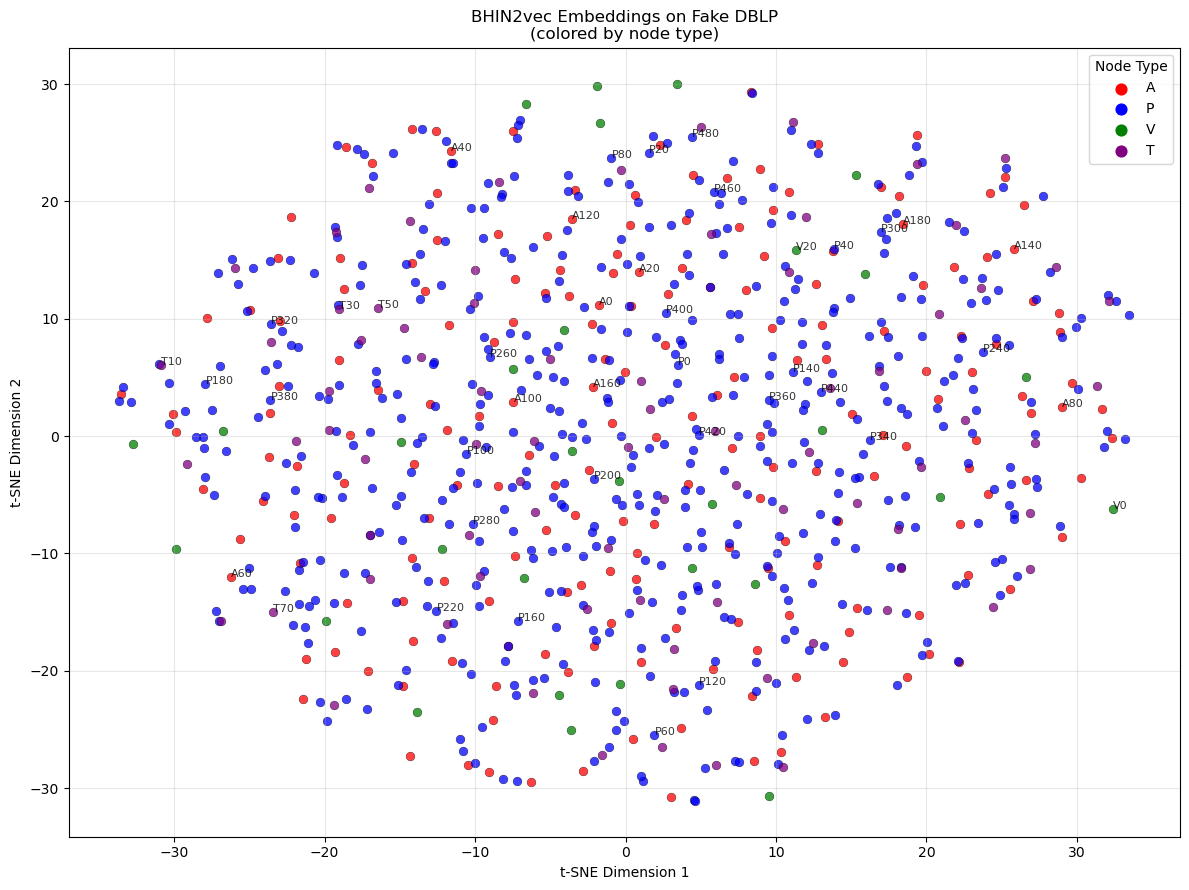

In [89]:
embeddings = model.node_embedding.weight.detach().cpu().numpy()
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
emb_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(12, 9))
colors = {'A':'red', 'P':'blue', 'V':'green', 'T':'purple'}

for i, node in enumerate(G.nodes()):
    typ = node_type_dict[node]
    plt.scatter(emb_2d[i, 0], emb_2d[i, 1], 
                c=colors[typ], s=40, alpha=0.75, edgecolors='k', linewidth=0.3)
    
    if i % 20 == 0:
        plt.annotate(node, (emb_2d[i, 0], emb_2d[i, 1]), 
                     fontsize=8, alpha=0.8)

plt.title("BHIN2vec Embeddings on Fake DBLP\n(colored by node type)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True, alpha=0.3)

# Add legend
for typ, color in colors.items():
    plt.scatter([], [], c=color, label=typ, s=60)
plt.legend(title="Node Type", loc="upper right")

plt.tight_layout()
plt.show()